#### Carnegie Mellon University - Tepper School of Business
#### 46-886 - Machine Learning Fundamentals
#### 22/23 - Mini 4 - Section M4 - Farahat
---

## Deliverable 1 
**Due Wednesday, March 22nd at 2:59 a.m. Pittsburgh time**

**This is  team assignment**. Please provide below the names of all team members who have contributed to this deliverable:

- Name of team member 1: Ronak Sharma (RonakSha)
- Name of team member 2: Hrishikesh Mysore Harishkumar (HMysoreH)
- Name of team member 3: Amitesh Chanda (AmiteshC)
- Name of team member 4: Amit Garg (akg2)
- Name of team member 5 (if applicable): Ayan Anandkumar Saraf
---

*This deliverable consists of **two** Problems. Both problems require you to code in Python and answer one or more questions. Save a copy of this notebook and provide your solution by inserting code or Markdown text cells as appropriate.*

*You will need to submit two files through Canvas: 1) a completed Jupyter notebook (extension .ipynb) with your code and answers to each question (this file); and 2) an html rendering of your completed Jupyter notebook. Only one team member needs to submit the files on Canvas on behalf of the rest of the team.*

### Problem 1 (40 points)

In this problem we will examine this dataset using k-means clustering to see if we can find any ‘natural groups’ in the loan applicants.

The dataset <loans.csv> is posted on Canvas. The variables are as follows:

-  Monthly loan installment in dollars
-  log(annual income)
-  FICO score
-  Revolving balance in thousands of dollars
-  Number of inquiries in the past six months
-  Number of derogatory public records
-  default  (1 if the loan was not repaid in full, 0 otherwise)


#### Part (a)
Read in the dataset <loans.csv> and standardize it. Print the first 5 rows.


In [25]:
#conda install -c conda-forge scikit-plot

In [26]:
#conda update -n base -c defaults conda

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scikitplot as skplt

In [28]:
df = pd.read_csv ('loans.csv')
df

,default,installment,log_income,fico_score,rev_balance,inquiries,records
0,0,829,4.93,737,28.85,0,0
1,0,228,4.81,707,33.62,0,0
2,0,367,4.51,682,3.51,1,0
3,0,162,4.93,712,33.67,1,0
4,0,103,4.91,667,4.74,0,0
...,...,...,...,...,...,...,...
9511,1,345,5.29,672,215.37,2,0
9512,1,258,4.84,722,0.18,5,0
9513,1,98,4.60,687,10.04,8,0
9514,1,352,4.70,692,0.00,5,0


In [29]:
pd.options.display.max_columns = None

In [30]:
scaler = StandardScaler()
scaler.fit(df)

StandardScaler()

In [31]:
scaler.mean_

array([1.59836066e-01, 3.20142077e+02, 4.74865595e+00, 7.10841950e+02,
       1.69889481e+01, 1.57292980e+00, 6.22110130e-02])

In [32]:
scaler.scale_

array([  0.36645395, 207.05566989,   0.26500302,  37.95425209,
        33.71957966,   2.20021367,   0.26239173])

In [33]:
standardized_df = df.copy()
standardized_array = scaler.transform(standardized_df)

In [34]:
standardized_array = pd.DataFrame(scaler.transform(standardized_df))
standardized_df[:] = standardized_array

In [35]:
standardized_df.head (5)

,default,installment,log_income,fico_score,rev_balance,inquiries,records
0,-0.43617,2.457590,0.684309,0.689199,0.351756,-0.714899,-0.237092
1,-0.43617,-0.445011,0.231484,-0.101226,0.493216,-0.714899,-0.237092
2,-0.43617,0.226306,-0.900578,-0.759914,-0.399737,-0.260397,-0.237092
3,-0.43617,-0.763766,0.684309,0.030512,0.494699,-0.260397,-0.237092
4,-0.43617,-1.048714,0.608839,-1.155126,-0.363259,-0.714899,-0.237092


In [36]:
standardized_df.mean()

default        4.173953e-16
installment   -4.567828e-16
log_income    -9.336094e-16
fico_score     6.878576e-16
rev_balance    5.723085e-16
inquiries     -1.977994e-14
records       -1.892483e-15
dtype: float64

In [37]:
standardized_df.std()

default        1.000053
installment    1.000053
log_income     1.000053
fico_score     1.000053
rev_balance    1.000053
inquiries      1.000053
records        1.000053
dtype: float64

#### Part (b)
Set the random state to 886 (to ensure reproducibility of results across teams) and run the k-means algorithm on the standardized dataset with k = 4 and n_init = 100. 

i. Provide a snapshot of the 4 centroids found by the k-means algorithm

ii. What’s the % reduction in the sum of squared distances when we go from k=1 (baseline) to k=4?

In [38]:
k = 1

In [39]:
clustering_kmeans_1 = KMeans(n_clusters=k, n_init=100, random_state=886)
#default values: n_clusters=8; n_init=10; 
clustering_kmeans_1.fit(standardized_df)

KMeans(n_clusters=1, n_init=100, random_state=886)

In [40]:
inertia_K_1 = clustering_kmeans_1.inertia_
inertia_K_1

66612.00000000004

In [41]:
k = 4

In [42]:
clustering_kmeans_2 = KMeans(n_clusters=k, n_init=100, random_state=886)
#default values: n_clusters=8; n_init=10; 
clustering_kmeans_2.fit(standardized_df)

KMeans(n_clusters=4, n_init=100, random_state=886)

In [43]:
inertia_K_2 = clustering_kmeans_2.inertia_
inertia_K_2

40973.44388327161

In [44]:
# 1. Provide a snapshot of the 4 centroids found by the k-means algorithm.
clustering_kmeans_2.cluster_centers_

array([[-0.43616958, -0.49936476, -0.39865681, -0.01260704, -0.23265728,
        -0.09184759, -0.23709213],
       [ 0.24235674, -0.12433312,  0.04627484, -0.59090971, -0.15352196,
         0.29237452,  3.82120981],
       [ 2.28444198,  0.02874751, -0.17374389, -0.32211506, -0.04753792,
         0.33622145, -0.23709213],
       [-0.36718165,  1.04340885,  0.90507371,  0.32877145,  0.53979397,
        -0.05412087, -0.23556279]])

In [48]:
df_centroids = pd.DataFrame(clustering_kmeans_2.cluster_centers_, columns=standardized_df.columns)

<AxesSubplot:>

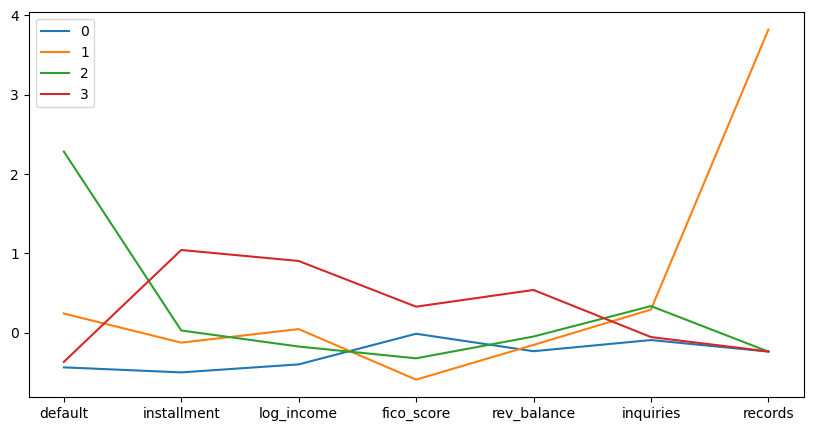

In [49]:
df_centroids.T.plot(figsize = (10,5))

In [50]:
# ii. What’s the % reduction in the sum of squared distances when we go from k=1 (baseline) to k=4?
## should baseline have n_init = 1 or 100?
percentage_reduction_in_sum_of_squared_distances = (inertia_K_1 - inertia_K_2)/inertia_K_1 * 100
percentage_reduction_in_sum_of_squared_distances

38.48939547938572

#### Part (c)
Try to provide a simple description, or descriptive label, to each of the 4 clusters you’ve identified in part (b).

The parallel plot above for the 4 clusters created from our Kmeans algorithm shows us the following details for each cluster created: 

- Cluster 0 - This cluster contains applicants who's monthly loan installment was relatively low, their fico score was high, and their number of inquiries and deragatory public records was low. With all this in mind, we believe this cluster contains applicants who have relatively low income and who did not apply for a huge loan. Cluster 0 refers to loans with lowest number of defaults, low revolving balance and fewer number of inquiries.
    
- Cluster 1 - This cluster contains applications who's income was relatively high, their FICO score was low, their inquiries were high and the number of their deragatory public records was very high. With this in mind, we believe this cluster contains applicants who had relatively high income, but failed to pay their installments on time resulting in a low FICO score. Cluster 1 refers to loans with highest number of derogatory public records and customers with lowest FICO Scores.

- Cluster 2 - This cluster contains applicants who had high monthly installments, relatively low FICO score, and an average amount of inquiries and deragatory public records. With this in mind, we believe this cluster is based on applicants who failed to pay their loan in full as their monthly installments were also high. Cluster 2 refers to loans with highest number of defaults. 

- Cluster 3 - This cluster contains applicants who's monthly installments and income were really high. Their FICO score was high as well and they had a low number of inquiries and deragatory public records. With this in mind, we believe this cluster contains applicants who took look large loans but they were able to pay them back in full as they had a high income resulting in a low default value. Cluster 3 refers to loans with high monthly installments, customers with high income, FICO Scores and revolving balance.


In [58]:
clustering_kmeans_2.labels_

array([3, 0, 0, ..., 2, 2, 2])

In [59]:
print ("The first observation belongs to 4th cluster, second observation belongs to 1st cluster & so on.")

The first observation belongs to 4th cluster, second observation belongs to 1st cluster & so on.


#### Part (d)
Construct an elbow plot for values of k between 1 and 10. Comment on where a clear "elbow" point exists on the plot.

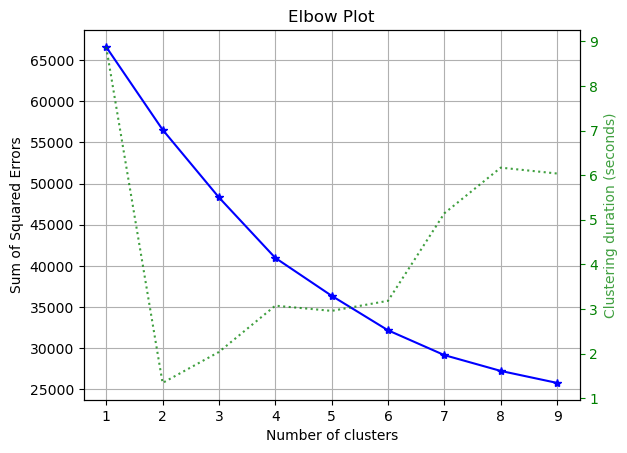

In [60]:
skplt.cluster.plot_elbow_curve(clustering_kmeans_2, standardized_df, cluster_ranges=range(1, 10))
plt.show()

In [72]:
print ("Looking at the plot, we can say that there is no clear elbow point that exists and for sure a judgement is required to decide on the number of clusters k. But, cluster 7 shows total reduction in sum of squared error of 87.5% (65000-30000)/ (65000-25000) assuming 100% reduction from cluster 1 to cluster 9.")

Looking at the plot, we can say that there is no clear elbow point that exists and for sure a judgement is required to decide on the number of clusters k. But, cluster 7 shows total reduction in sum of squared error of 87.5% (65000-30000)/ (65000-25000) assuming 100% reduction from cluster 1 to cluster 9.


----

### Problem 2 (60 points)

In this problem I ask you to analyze data on Covid-19 vaccination rates in the US in terms of 15 census variables used by the CDC to determine the degree of social vulnerability of each of 3,141 counties. This is the same dataset you've seen in the final exam for 46-881. 

I'm providing a random 70-30 train / test split of the counties in two data files available on Canvas accompanying this deliverable: <vaccination_trainset.csv> and <vaccination_testset.csv>. Each row corresponds to a unique county. A data dictionary is provided below: 

| Column name |	Description |
| :-----------| :------------------|
| STATE	      | State abbreviation |
| COUNTY	  | County name        |
| EP_POV      |	Percentage of persons below poverty estimate|
| EP_UNEMP    |	Unemployment Rate estimate|
| EP_PCI      |	Per capita income estimate|
| EP_NOHSDP   |	Percentage of persons with no high school diploma (age 25+) estimate|
| EP_AGE65    |	Percentage of persons aged 65 and older estimate|
| EP_AGE17    |	Percentage of persons aged 17 and younger estimate|
| EP_DISABL   |	Percentage of civilian noninstitutionalized population with a disability estimate|
| EP_SNGPNT   |	Percentage of single parent households with children under 18 estimate|
| EP_MINRTY   |	Percentage minority (all persons except white, non-Hispanic) estimate|
| EP_LIMENG   |	Percentage of persons (age 5+) who speak English "less than well" estimate|
| EP_MUNIT    |	Percentage of housing in structures with 10 or more units estimate|
| EP_MOBILE   |	Percentage of mobile homes estimate|
| EP_CROWD    |	Percentage of occupied housing units with more people than rooms estimate|
| EP_NOVEH    |	Percentage of households with no vehicle available estimate|
| EP_GROUPQ   |	Percentage of persons in group quarters estimate|
| V_PCT_65YRS |	Percent of population 65 years and older fully vaccinated| 

The data on vaccination rates is current as of October 14th, 2021. Approximately 395 of the 3,141 counties had at least one missing variable element and these counties have been deleted (possibly biasing the data, but do not worry about this for the purposes of this exam). More information on the data and its context is available on the CDC website.  

#### Part (a)
Use Scikit-Learn to construct a linear regression model on the train set with the percent of population 65 years and older fully vaccinated (V_PCT_65YRS) as the dependent variable and an appropriate selection of the 15 social vulnerability variables (those with the “EP” prefix) as the independent variables. Outline clearly the procedure you followed to arrive at your final regression model starting from the data provided. Print the intercept and model coefficients.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [74]:
import statsmodels.api as sm
#import statsmodels.formula.api as smf

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [76]:
df = pd.read_csv("vaccination_trainset.csv")
df

,STATE,COUNTY,EP_POV,EP_UNEMP,EP_PCI,EP_NOHSDP,EP_AGE65,EP_AGE17,EP_DISABL,EP_SNGPNT,EP_MINRTY,EP_LIMENG,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,V_PCT_65YRS
0,AL,Blount,14.4,4.1,22656,19.8,17.8,23.4,14.2,7.0,12.9,1.7,0.9,25.2,1.6,4.2,0.9,50.1
1,AL,Butler,23.5,6.7,20430,15.4,19.0,22.8,17.7,10.5,48.1,0.5,1.3,26.2,1.8,7.8,1.6,59.6
2,AL,Calhoun,18.6,8.8,24706,15.9,16.8,21.9,20.8,10.4,27.5,1.0,3.7,14.7,1.7,5.8,2.7,74.6
3,AL,Chambers,16.6,5.0,22827,18.6,18.9,20.7,16.7,9.7,44.2,0.1,4.0,14.0,3.0,7.3,1.5,48.8
4,AL,Colbert,16.3,5.9,24918,15.6,19.3,21.3,18.7,8.2,21.3,0.3,2.2,9.3,0.4,6.1,0.8,73.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1917,MS,Tallahatchie,30.6,14.2,14943,31.1,14.3,20.0,16.2,13.6,64.9,1.7,1.1,27.0,2.1,10.6,23.1,69.5
1918,NY,Bronx,29.1,10.5,20850,28.0,12.1,25.1,14.8,19.1,90.7,15.8,68.1,0.1,12.3,58.5,2.9,78.0
1919,NC,Greene,25.7,9.7,18339,25.9,15.2,20.9,23.4,12.3,53.1,5.0,1.2,38.4,3.5,7.4,11.5,53.7
1920,SD,Ziebach,41.0,23.1,14943,15.9,9.0,32.0,10.9,17.2,76.4,0.5,6.9,27.2,14.2,12.2,0.0,48.5


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1922 entries, 0 to 1921
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   STATE        1922 non-null   object 
 1   COUNTY       1922 non-null   object 
 2   EP_POV       1922 non-null   float64
 3   EP_UNEMP     1922 non-null   float64
 4   EP_PCI       1922 non-null   int64  
 5   EP_NOHSDP    1922 non-null   float64
 6   EP_AGE65     1922 non-null   float64
 7   EP_AGE17     1922 non-null   float64
 8   EP_DISABL    1922 non-null   float64
 9   EP_SNGPNT    1922 non-null   float64
 10  EP_MINRTY    1922 non-null   float64
 11  EP_LIMENG    1922 non-null   float64
 12  EP_MUNIT     1922 non-null   float64
 13  EP_MOBILE    1922 non-null   float64
 14  EP_CROWD     1922 non-null   float64
 15  EP_NOVEH     1922 non-null   float64
 16  EP_GROUPQ    1922 non-null   float64
 17  V_PCT_65YRS  1922 non-null   float64
dtypes: float64(15), int64(1), object(2)
memory usage

In [78]:
y_train = df["V_PCT_65YRS"]

In [79]:
X_train = df.drop(["V_PCT_65YRS", "STATE","COUNTY"], axis=1)

In [80]:
X_train1 = sm.add_constant(X_train)
mod = sm.OLS(y_train, X_train1).fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:            V_PCT_65YRS   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     40.44
Date:                Sun, 19 Mar 2023   Prob (F-statistic):          5.61e-103
Time:                        16:04:35   Log-Likelihood:                -7958.2
No. Observations:                1922   AIC:                         1.595e+04
Df Residuals:                    1906   BIC:                         1.604e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         74.2645      8.818      8.422      0.0

#### Part (b)
What is the out-of-sample (i.e. test set) RMSE?

In [81]:
df_1 = pd.read_csv("vaccination_testset.csv")
df_1

,STATE,COUNTY,EP_POV,EP_UNEMP,EP_PCI,EP_NOHSDP,EP_AGE65,EP_AGE17,EP_DISABL,EP_SNGPNT,EP_MINRTY,EP_LIMENG,EP_MUNIT,EP_MOBILE,EP_CROWD,EP_NOVEH,EP_GROUPQ,V_PCT_65YRS
0,AL,Autauga,15.4,4.2,29372,11.3,14.6,24.2,19.3,7.5,25.0,0.8,3.8,18.4,1.4,5.6,1.0,62.2
1,AL,Coffee,15.1,5.9,27577,13.8,16.3,23.7,17.7,9.7,29.4,1.4,0.9,13.6,1.4,6.0,1.2,69.1
2,AL,Dale,18.4,8.8,23837,14.2,16.1,23.4,21.3,8.2,31.0,1.0,1.2,18.2,1.7,5.5,2.6,72.5
3,AL,Lauderdale,15.2,5.3,27189,12.6,19.3,20.0,14.7,7.6,15.2,0.6,5.3,9.1,1.2,7.0,2.4,71.1
4,AL,Marshall,21.7,5.1,23833,19.1,16.8,24.9,15.5,9.2,18.8,4.0,1.6,14.8,2.6,4.8,1.1,75.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,NM,McKinley,36.0,15.7,15278,24.6,11.5,29.3,16.7,14.1,91.2,3.1,1.2,23.5,13.5,11.3,1.0,99.9
820,SC,Marlboro,26.0,13.0,17034,24.1,16.7,20.4,21.6,12.5,60.8,0.8,1.0,27.8,3.0,13.0,10.8,64.0
821,SD,Todd,55.1,13.2,10931,22.1,7.5,40.3,9.1,25.6,91.8,0.5,6.4,17.8,13.5,21.6,0.4,81.7
822,MS,Claiborne,44.0,15.6,13503,22.6,15.3,21.8,14.6,15.7,88.3,0.4,5.0,37.8,5.7,10.4,8.0,77.8


In [82]:
y_test = df_1["V_PCT_65YRS"]

In [83]:
X_test = df_1.drop(["V_PCT_65YRS", "STATE","COUNTY"], axis=1)

In [84]:
X_test1 = sm.add_constant(X_test)
mod_test_predictions = mod.predict(X_test1)

In [85]:
mean_squared_error(y_test, mod_test_predictions, squared=False)

15.005259346078265

#### Part (c)
Repeat the prediction of Parts (a) and (b) but with a KNN algorithm (with k = 5). What is the out-of-sample (i.e. test set) RMSE in this case?   

In [86]:
scaler = StandardScaler()
scaler.fit(X_train)

# Standardize the train set
standardized_X_train = X_train.copy()
standardized_train_array = scaler.transform(standardized_X_train)
standardized_X_train[:] = standardized_train_array

## Standardize the test set
# To standardize the test data set - we use "mean and std dev" calcuated from "train data set" 
# i.e., use the "scaler" from train data set.
standardized_X_test = X_test.copy()
standardized_test_array = scaler.transform(standardized_X_test)
standardized_X_test[:] = standardized_test_array

In [87]:
k = 5
knn_mod = KNeighborsRegressor(n_neighbors=k)
knn_mod.fit(standardized_X_train, y_train)
knn_pred = knn_mod.predict(standardized_X_test)

In [88]:
# Root Mean squared error (RMSE)
# Compare "test data" with "KNN predicted data"
mean_squared_error(y_test, knn_pred, squared=False)

15.529295803588127

----